# Feature Extraction Demonstration
This outlines how a audio .wav file is converted into a chromagram, and how the chord can be detected using that chromagram.
This example will be done on a C chord.

In [1]:
# Imports
import librosa
import numpy as np
%matplotlib inline

### Loading File and Extracting Features
The *librosa* library is used to preform low-level feature extraction such as chromagrams, Mel spectrogram, MFCC, etc.

The audio file is loaded and decoded as a *time series* `y`, represented as a one-dimensional NumPy floating point array. The variable `sr` contains the sampling rate of `y`, that is, the number of samples per second of audio.
By default, all audio is mixed to mono and resampled to 22050 Hz at load time. 

In [2]:
# Load C major chord audio file
y, sr = librosa.load('chords-test/C_acoustic_guitar_fender_fa_series_1.wav')

# Compute chroma features
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)

# Show first 5 time steps
# print(chroma[:, :5])

# Average chroma values across time to get a single vector per chord
chroma_mean = chroma.mean(axis=1)
print(f"Average chroma vector: \n{chroma_mean}")  # show average chroma vector

Average chroma vector: 
[0.9801353  0.17391993 0.19715185 0.10917716 0.36052847 0.09246563
 0.0876564  0.38373512 0.13390033 0.16097637 0.15296954 0.21582028]


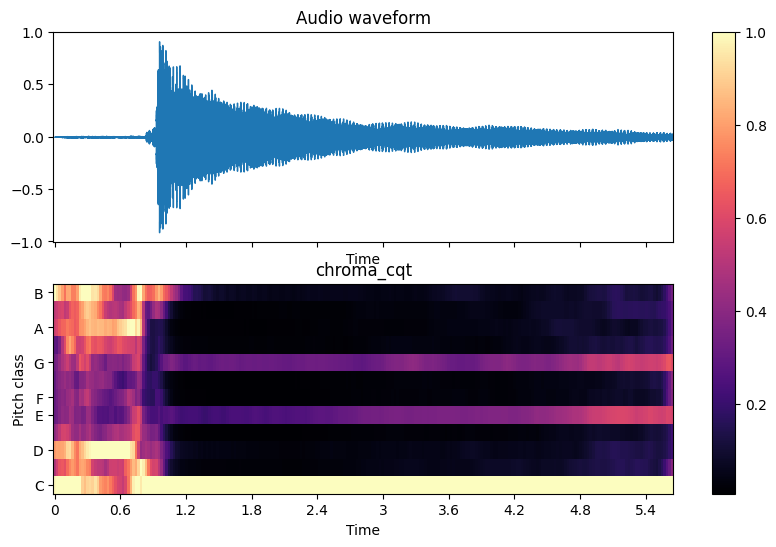

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10, 6))
img = librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set(title='Audio waveform')
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='chroma_cqt')
fig.colorbar(img, ax=ax)